# Input Specific Neural Networks (ISNN) Assignment

Based on: *Input Specific Neural Networks* by Jadoon et al.

This notebook implements:
- **ISNN-1** and **ISNN-2** in PyTorch (automatic backprop)
- **ISNN-1** and **ISNN-2** manually in NumPy (manual backprop)
- Dataset generation for both toy problems from Section 3.1
- Training + evaluation on both datasets
- Plots matching Figures 3, 4, 5, 6 from the paper

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import qmc  # for latin hypercube sampling

matplotlib.rcParams['figure.dpi'] = 100
torch.manual_seed(42)
np.random.seed(42)

print("torch version:", torch.__version__)
print("numpy version:", np.__version__)

torch version: 2.11.0+cpu
numpy version: 2.3.2


## Section 1: Dataset Generation

We generate two toy datasets as described in Section 3.1 of the paper.

**Function 1 (additive split):**
$$f = e^{-0.5x} + \log(1 + e^{0.4y}) + \tanh(t) + \sin(z) - 0.4$$

**Function 2 (multiplicative split):**
$$g = f_x \cdot f_y \cdot f_z \cdot f_t$$
where $f_x = e^{-0.3x},\ f_y = (0.15y)^2,\ f_t = \tanh(0.3t),\ f_z = 0.2\sin(0.5z+2)+0.5$

Training range: $[0, 4]$ for dataset 1, $[0, 4]$ for dataset 2.
Test range: $[0, 6]$ for dataset 1, $[0, 10]$ for dataset 2.

In [2]:
def latin_hypercube(n_samples, n_dims, low, high):
    """Simple Latin Hypercube Sampling — fills space more evenly than random."""
    sampler = qmc.LatinHypercube(d=n_dims, seed=42)
    raw = sampler.random(n=n_samples)        # values in [0, 1]
    scaled = qmc.scale(raw, low, high)       # rescale to desired range
    return scaled


def func1(x, y, t, z):
    """Additive toy function from Eq. (12) in the paper.
    Convex in x, convex+monotone in y, monotone in t, arbitrary in z.
    """
    return np.exp(-0.5 * x) + np.log(1 + np.exp(0.4 * y)) + np.tanh(t) + np.sin(z) - 0.4


def func2(x, y, t, z):
    """Multiplicative toy function from Eq. (13) in the paper.
    Same structural properties as func1 but multiplicatively coupled.
    """
    fx = np.exp(-0.3 * x)
    fy = (0.15 * y) ** 2
    ft = np.tanh(0.3 * t)
    fz = 0.2 * np.sin(0.5 * z + 2) + 0.5
    return fx * fy * ft * fz


def make_dataset(fn, n_train, n_test, train_range, test_range):
    """Generate training and test datasets using LHS."""
    X_tr = latin_hypercube(n_train, 4, train_range[0], train_range[1])
    y_tr = fn(X_tr[:,0], X_tr[:,1], X_tr[:,2], X_tr[:,3]).reshape(-1, 1)

    # test data spans a bigger range to check extrapolation
    X_te = latin_hypercube(n_test, 4, test_range[0], test_range[1])
    y_te = fn(X_te[:,0], X_te[:,1], X_te[:,2], X_te[:,3]).reshape(-1, 1)

    return X_tr, y_tr, X_te, y_te


# Dataset 1 — additive function
X1_train, y1_train, X1_test, y1_test = make_dataset(func1, 500, 5000, [0, 4], [0, 6])

# Dataset 2 — multiplicative function
X2_train, y2_train, X2_test, y2_test = make_dataset(func2, 500, 5000, [0, 4], [0, 10])

print("Dataset 1 — train:", X1_train.shape, "test:", X1_test.shape)
print("Dataset 2 — train:", X2_train.shape, "test:", X2_test.shape)

Dataset 1 — train: (500, 4) test: (5000, 4)
Dataset 2 — train: (500, 4) test: (5000, 4)


---
## Section 2: PyTorch Implementations

### Activation functions
From Eq. (11) in the paper:
- $\sigma_{mc}(x) = \log(1 + e^x)$ — softplus; convex AND monotone non-decreasing
- $\sigma_m(x) = \sigma_a(x) = \frac{1}{1+e^{-x}}$ — sigmoid; just monotone (or arbitrary)

In [3]:
# ----------------------------------------------------------------
#  Activation functions
# ----------------------------------------------------------------

def sigma_mc(x):
    """Softplus — convex and monotonically non-decreasing."""
    return torch.log(1 + torch.exp(x))

def sigma_m(x):
    """Sigmoid — only monotone, not necessarily convex."""
    return torch.sigmoid(x)

def sigma_a(x):
    """Sigmoid again — arbitrary use case (no convexity requirement)."""
    return torch.sigmoid(x)

### ISNN-1 in PyTorch

Architecture based on Equations (1)–(5) in the paper.

Each input type (x, y, t, z) gets its own branch with separate weights. The branches for y, z, t pass their final hidden states into the first layer of the x-branch alongside x itself. The key constraints:
- **x-branch** (layers h≥1): weights must be non-negative → use `F.softplus` or `abs()` on weight
- **y-branch** weights: non-negative, activation `sigma_mc`
- **t-branch** weights: non-negative, activation `sigma_m`
- **z-branch**: unconstrained weights, activation `sigma_a`
- The cross-weight **W_xy** must be non-negative too

In [ ]:
import torch.nn.functional as F


class ISNN1(nn.Module):
    """
    Type 1 Input Specific Neural Network.
    Reproduces the architecture from Figure 1 / Eqs (1)-(5).

    Branches run independently, then merge into the x branch at layer 1.
    Constraints are enforced by taking abs() of weight matrices
    wherever non negativity is required.
    """

    def __init__(self, dim_x=1, dim_y=1, dim_t=1, dim_z=1,
                 n_hidden=10, n_layers=2):
        super().__init__()

        self.n_hidden = n_hidden
        self.n_layers = n_layers

        # ---- y branch (convex + monotone) ----
        y_layers = []
        in_dim = dim_y
        for _ in range(n_layers):
            y_layers.append(nn.Linear(in_dim, n_hidden))
            in_dim = n_hidden
        self.y_branch = nn.ModuleList(y_layers)

        # ---- z-branch (arbitrary) ----
        z_layers = []
        in_dim = dim_z
        for _ in range(n_layers):
            z_layers.append(nn.Linear(in_dim, n_hidden))
            in_dim = n_hidden
        self.z_branch = nn.ModuleList(z_layers)

        # ---- t-branch (monotone only) ----
        t_layers = []
        in_dim = dim_t
        for _ in range(n_layers):
            t_layers.append(nn.Linear(in_dim, n_hidden))
            in_dim = n_hidden
        self.t_branch = nn.ModuleList(t_layers)

        # ---- x-branch layer 0: merges all branches + x input ----
        # This is the first x layer — W_xx0 can be anything, W_xy/W_xz/W_xt >= 0
        self.x0_to_x1 = nn.Linear(dim_x, n_hidden, bias=True)
        self.y_to_x1  = nn.Linear(n_hidden, n_hidden, bias=False)  # W_xy must be >= 0
        self.z_to_x1  = nn.Linear(n_hidden, n_hidden, bias=False)  # W_xz: unconstrained
        self.t_to_x1  = nn.Linear(n_hidden, n_hidden, bias=False)  # W_xt must be >= 0

        # ---- x-branch layers 1+ (W_xx must be non-negative here) ----
        x_layers = []
        for _ in range(n_layers - 1):
            x_layers.append(nn.Linear(n_hidden, n_hidden))
        self.x_branch = nn.ModuleList(x_layers)

        # ---- final output layer (no activation, unconstrained) ----
        self.output_layer = nn.Linear(n_hidden, 1)


    def forward(self, x, y, t, z):
        # --- run y-branch with sigma_mc (convex + monotone) ---
        hy = y
        for layer in self.y_branch:
            W_pos = layer.weight.abs()  # enforce non-negative weights
            hy = sigma_mc(F.linear(hy, W_pos, layer.bias))

        # --- run z-branch with sigma_a (no constraint) ---
        hz = z
        for layer in self.z_branch:
            hz = sigma_a(layer(hz))   # weights are free here

        # --- run t-branch with sigma_m (monotone only) ---
        ht = t
        for layer in self.t_branch:
            W_pos = layer.weight.abs()  # non-negative for monotonicity
            ht = sigma_m(F.linear(ht, W_pos, layer.bias))

        # --- merge into first x-layer ---
        # W_xx0 is free, W_xy and W_xt must be >= 0, W_xz is free
        W_xy_pos = self.y_to_x1.weight.abs()
        W_xt_pos = self.t_to_x1.weight.abs()

        pre_act = (self.x0_to_x1(x)
                   + F.linear(hy, W_xy_pos)
                   + self.z_to_x1(hz)
                   + F.linear(ht, W_xt_pos))
        hx = sigma_mc(pre_act)

        # --- deeper x-layers: W_xx >= 0 required for convexity ---
        for layer in self.x_branch:
            W_pos = layer.weight.abs()
            hx = sigma_mc(F.linear(hx, W_pos, layer.bias))

        # --- output ---
        out = self.output_layer(hx)
        return out


# quick sanity check
model_check = ISNN1()
dummy = torch.randn(5, 1)
out = model_check(dummy, dummy, dummy, dummy)
print("ISNN-1 output shape:", out.shape)

ISNN-1 output shape: torch.Size([5, 1])


In [5]:
class ISNN2(nn.Module):
    """
    Type-2 Input Specific Neural Network.
    Reproduces the architecture from Figure 2 / Eqs (6)-(10).

    Key difference from ISNN-1: all branches run in parallel for every layer,
    and x0 is passed through as a skip connection to each x-layer.
    This gives the network more representational power (less depth per branch).
    """

    def __init__(self, dim_x=1, dim_y=1, dim_t=1, dim_z=1,
                 n_hidden=15, n_layers=2):
        super().__init__()

        self.n_layers = n_layers

        # ---- parallel branches — all same depth ----
        # y-branch: sigma_mc, weights >= 0
        y_layers = [nn.Linear(dim_y, n_hidden)]
        for _ in range(n_layers - 2):
            y_layers.append(nn.Linear(n_hidden, n_hidden))
        self.y_branch = nn.ModuleList(y_layers)

        # z-branch: sigma_a, weights unconstrained
        z_layers = [nn.Linear(dim_z, n_hidden)]
        for _ in range(n_layers - 2):
            z_layers.append(nn.Linear(n_hidden, n_hidden))
        self.z_branch = nn.ModuleList(z_layers)

        # t-branch: sigma_m, weights >= 0
        t_layers = [nn.Linear(dim_t, n_hidden)]
        for _ in range(n_layers - 2):
            t_layers.append(nn.Linear(n_hidden, n_hidden))
        self.t_branch = nn.ModuleList(t_layers)

        # ---- x-branch layer 0 (first layer combines all inputs) ----
        # W_xx0, W_xy0, W_xz0, W_xt0 — note W_xy0 and W_xt0 must be >= 0
        self.x_init = nn.Linear(dim_x + n_hidden + n_hidden + n_hidden, n_hidden)

        # ---- x-branch layers h=1..H-1 ----
        # W_xx >= 0 (non-negative for convexity)
        # W_xx0 (skip from original x0) can be anything
        # W_xy, W_xt >= 0; W_xz unconstrained
        self.Wxx_layers  = nn.ModuleList([nn.Linear(n_hidden, n_hidden, bias=False) for _ in range(n_layers - 1)])
        self.Wxx0_layers = nn.ModuleList([nn.Linear(dim_x,    n_hidden, bias=False) for _ in range(n_layers - 1)])
        self.Wxy_layers  = nn.ModuleList([nn.Linear(n_hidden, n_hidden, bias=False) for _ in range(n_layers - 1)])
        self.Wxz_layers  = nn.ModuleList([nn.Linear(n_hidden, n_hidden, bias=False) for _ in range(n_layers - 1)])
        self.Wxt_layers  = nn.ModuleList([nn.Linear(n_hidden, n_hidden, bias=False) for _ in range(n_layers - 1)])
        self.x_biases    = nn.ParameterList([nn.Parameter(torch.zeros(n_hidden)) for _ in range(n_layers - 1)])

        self.output_layer = nn.Linear(n_hidden, 1)


    def forward(self, x0, y0, t0, z0):
        # run y-branch
        hy = y0
        for layer in self.y_branch:
            W_pos = layer.weight.abs()
            hy = sigma_mc(F.linear(hy, W_pos, layer.bias))

        # run z-branch
        hz = z0
        for layer in self.z_branch:
            hz = sigma_a(layer(hz))

        # run t-branch
        ht = t0
        for layer in self.t_branch:
            W_pos = layer.weight.abs()
            ht = sigma_m(F.linear(ht, W_pos, layer.bias))

        # first x-layer — concat x0 with all branch outputs as in Eq (9)
        # W_xy and W_xt are constrained; W_xz and W_xx0 are free
        # We handle this by splitting the weight of x_init
        all_inputs = torch.cat([x0, hy, hz, ht], dim=-1)
        # We can't cleanly enforce partial non-negativity with a single Linear,
        # so we split the weight manually into parts
        d_x = x0.shape[-1]
        d_h = hy.shape[-1]

        W = self.x_init.weight   # shape: [n_hidden, d_x + 3*n_hidden]
        b = self.x_init.bias

        # slice the weight into its parts — xx0 free, xy pos, xz free, xt pos
        W_xx0 = W[:, :d_x]                   # free
        W_xy  = W[:, d_x : d_x+d_h].abs()    # non-negative
        W_xz  = W[:, d_x+d_h : d_x+2*d_h]   # free
        W_xt  = W[:, d_x+2*d_h:].abs()       # non-negative

        pre = (F.linear(x0, W_xx0)
               + F.linear(hy, W_xy)
               + F.linear(hz, W_xz)
               + F.linear(ht, W_xt) + b)
        hx = sigma_mc(pre)

        # deeper x-layers with skip connections from x0
        # and updated hy, hz, ht from their respective branches
        # (in ISNN-2 the parallel branches continue updating each layer)
        for i in range(len(self.Wxx_layers)):
            Wxx  = self.Wxx_layers[i].weight.abs()   # non-negative
            Wxx0 = self.Wxx0_layers[i].weight        # free (skip connection)
            Wxy  = self.Wxy_layers[i].weight.abs()   # non-negative
            Wxz  = self.Wxz_layers[i].weight         # free
            Wxt  = self.Wxt_layers[i].weight.abs()   # non-negative
            b_i  = self.x_biases[i]

            pre = (F.linear(hx, Wxx)
                   + F.linear(x0, Wxx0)
                   + F.linear(hy, Wxy)
                   + F.linear(hz, Wxz)
                   + F.linear(ht, Wxt) + b_i)
            hx = sigma_mc(pre)

        return self.output_layer(hx)


# quick sanity check
model_check2 = ISNN2()
out2 = model_check2(dummy, dummy, dummy, dummy)
print("ISNN-2 output shape:", out2.shape)

ISNN-2 output shape: torch.Size([5, 1])


### PyTorch Training Helper

In [6]:
def to_tensors(*arrays):
    """Convert numpy arrays to float32 tensors."""
    return [torch.tensor(a, dtype=torch.float32) for a in arrays]


def train_pytorch_model(model, X_train, y_train, X_test, y_test,
                        n_epochs=30000, lr=1e-3, log_every=500):
    """
    Train an ISNN model using Adam and MSE loss.
    Returns the per-epoch training and test losses.
    """
    # unpack inputs — each column is one input variable
    x_tr, y_tr_in, t_tr, z_tr = [X_train[:, i:i+1] for i in range(4)]
    x_te, y_te_in, t_te, z_te = [X_test[:, i:i+1]  for i in range(4)]

    # convert to tensors
    x_tr, y_tr_in, t_tr, z_tr, y_tr_out = to_tensors(x_tr, y_tr_in, t_tr, z_tr, y_train)
    x_te, y_te_in, t_te, z_te, y_te_out = to_tensors(x_te, y_te_in, t_te, z_te, y_test)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.MSELoss()

    train_losses, test_losses = [], []

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(x_tr, y_tr_in, t_tr, z_tr)
        loss = loss_fn(pred, y_tr_out)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            pred_te = model(x_te, y_te_in, t_te, z_te)
            te_loss = loss_fn(pred_te, y_te_out)
        test_losses.append(te_loss.item())

        if (epoch + 1) % log_every == 0:
            print(f"  epoch {epoch+1:5d}  |  train: {loss.item():.4e}  |  test: {te_loss.item():.4e}")

    return np.array(train_losses), np.array(test_losses)


print("Training helpers defined.")

Training helpers defined.


### Train PyTorch Models on Dataset 1 (multiple inits)

In [7]:
N_INITS   = 5     # paper uses 10, we use 5 to keep runtime reasonable
N_EPOCHS  = 10000
LR        = 1e-3

# storage: shape (n_inits, n_epochs)
results_d1 = {"ISNN1_train": [], "ISNN1_test": [],
              "ISNN2_train": [], "ISNN2_test": []}

print("=== Dataset 1 — ISNN-1 ===")
for i in range(N_INITS):
    torch.manual_seed(i)
    m = ISNN1(n_hidden=10, n_layers=2)
    tr, te = train_pytorch_model(m, X1_train, y1_train, X1_test, y1_test,
                                  n_epochs=N_EPOCHS, lr=LR, log_every=N_EPOCHS)
    results_d1["ISNN1_train"].append(tr)
    results_d1["ISNN1_test"].append(te)
    print(f"  init {i+1}/{N_INITS} done")

print("\n=== Dataset 1 — ISNN-2 ===")
for i in range(N_INITS):
    torch.manual_seed(i)
    m = ISNN2(n_hidden=15, n_layers=2)
    tr, te = train_pytorch_model(m, X1_train, y1_train, X1_test, y1_test,
                                  n_epochs=N_EPOCHS, lr=LR, log_every=N_EPOCHS)
    results_d1["ISNN2_train"].append(tr)
    results_d1["ISNN2_test"].append(te)
    print(f"  init {i+1}/{N_INITS} done")

# convert to numpy arrays for easy stats
for k in results_d1:
    results_d1[k] = np.array(results_d1[k])

=== Dataset 1 — ISNN-1 ===
  epoch 10000  |  train: 8.3410e-04  |  test: 1.0426e-01
  init 1/5 done
  epoch 10000  |  train: 9.8641e-04  |  test: 9.8190e-02
  init 2/5 done
  epoch 10000  |  train: 3.2884e-05  |  test: 1.0544e-01
  init 3/5 done
  epoch 10000  |  train: 7.7566e-05  |  test: 6.3420e-02
  init 4/5 done
  epoch 10000  |  train: 2.9688e-04  |  test: 7.8891e-02
  init 5/5 done

=== Dataset 1 — ISNN-2 ===
  epoch 10000  |  train: 1.7751e-04  |  test: 2.6029e-01
  init 1/5 done
  epoch 10000  |  train: 1.5294e-04  |  test: 2.1641e-01
  init 2/5 done
  epoch 10000  |  train: 1.8710e-03  |  test: 4.8786e-02
  init 3/5 done
  epoch 10000  |  train: 4.1480e-04  |  test: 2.2202e-01
  init 4/5 done
  epoch 10000  |  train: 3.2919e-03  |  test: 2.3925e-01
  init 5/5 done


In [8]:
# Train on dataset 2
results_d2 = {"ISNN1_train": [], "ISNN1_test": [],
              "ISNN2_train": [], "ISNN2_test": []}

print("=== Dataset 2 — ISNN-1 ===")
for i in range(N_INITS):
    torch.manual_seed(i)
    m = ISNN1(n_hidden=10, n_layers=2)
    tr, te = train_pytorch_model(m, X2_train, y2_train, X2_test, y2_test,
                                  n_epochs=N_EPOCHS, lr=LR, log_every=N_EPOCHS)
    results_d2["ISNN1_train"].append(tr)
    results_d2["ISNN1_test"].append(te)
    print(f"  init {i+1}/{N_INITS} done")

print("\n=== Dataset 2 — ISNN-2 ===")
for i in range(N_INITS):
    torch.manual_seed(i)
    m = ISNN2(n_hidden=15, n_layers=2)
    tr, te = train_pytorch_model(m, X2_train, y2_train, X2_test, y2_test,
                                  n_epochs=N_EPOCHS, lr=LR, log_every=N_EPOCHS)
    results_d2["ISNN2_train"].append(tr)
    results_d2["ISNN2_test"].append(te)
    print(f"  init {i+1}/{N_INITS} done")

for k in results_d2:
    results_d2[k] = np.array(results_d2[k])

=== Dataset 2 — ISNN-1 ===
  epoch 10000  |  train: 6.1108e-05  |  test: 8.0645e-03
  init 1/5 done
  epoch 10000  |  train: 4.7633e-05  |  test: 6.8956e-03
  init 2/5 done
  epoch 10000  |  train: 1.1250e-04  |  test: 1.3701e-02
  init 3/5 done
  epoch 10000  |  train: 5.8757e-05  |  test: 6.4178e-03
  init 4/5 done
  epoch 10000  |  train: 1.5898e-04  |  test: 9.0828e-03
  init 5/5 done

=== Dataset 2 — ISNN-2 ===
  epoch 10000  |  train: 5.9965e-05  |  test: 1.0920e-02
  init 1/5 done
  epoch 10000  |  train: 6.7434e-05  |  test: 1.2473e-02
  init 2/5 done
  epoch 10000  |  train: 1.5649e-04  |  test: 1.6183e-02
  init 3/5 done
  epoch 10000  |  train: 5.9053e-05  |  test: 8.4936e-03
  init 4/5 done
  epoch 10000  |  train: 7.5988e-05  |  test: 1.6664e-02
  init 5/5 done


### Plots: Figures 3 and 5 (Training and Test Loss Curves)

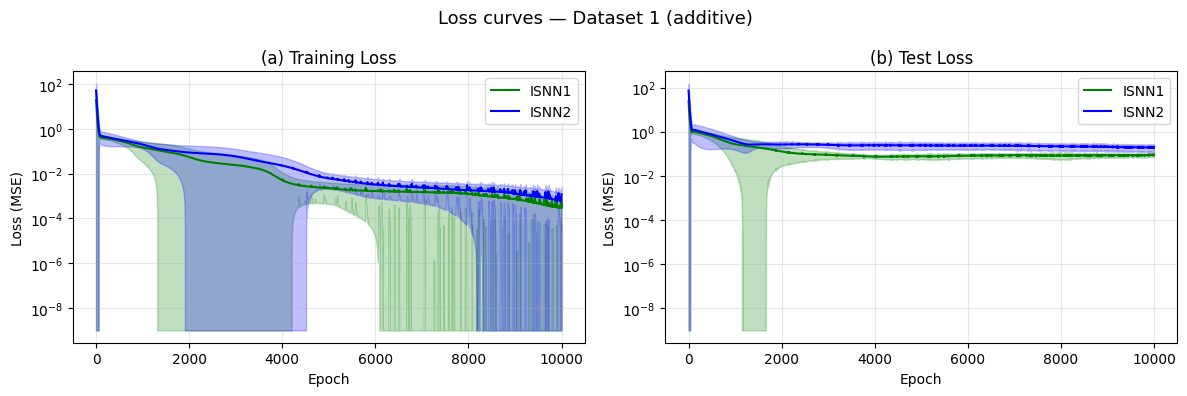

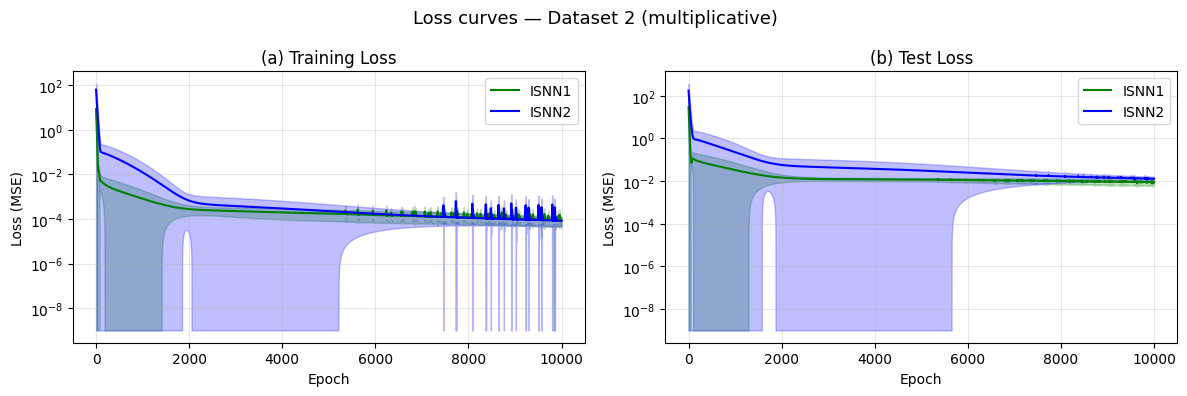

In [9]:
def plot_loss_curves(results, title_suffix, n_epochs):
    """Reproduce the style of Figures 3 and 5 from the paper."""

    epochs = np.arange(1, n_epochs + 1)
    colors = {"ISNN1": "green", "ISNN2": "blue"}

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for key, color in colors.items():
        tr  = results[f"{key}_train"]
        te  = results[f"{key}_test"]

        tr_mean, tr_std = tr.mean(0), tr.std(0)
        te_mean, te_std = te.mean(0), te.std(0)

        # training loss
        axes[0].semilogy(epochs, tr_mean, color=color, label=key)
        axes[0].fill_between(epochs,
                              np.clip(tr_mean - tr_std, 1e-9, None),
                              tr_mean + tr_std,
                              alpha=0.25, color=color)

        # test loss
        axes[1].semilogy(epochs, te_mean, color=color, label=key)
        axes[1].fill_between(epochs,
                              np.clip(te_mean - te_std, 1e-9, None),
                              te_mean + te_std,
                              alpha=0.25, color=color)

    for ax, title in zip(axes, ["(a) Training Loss", "(b) Test Loss"]):
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss (MSE)")
        ax.set_title(title)
        ax.legend()
        ax.grid(True, which='both', alpha=0.3)

    fig.suptitle(f"Loss curves — {title_suffix}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"loss_curves_{title_suffix.replace(' ','_')}.png", dpi=120, bbox_inches='tight')
    plt.show()


plot_loss_curves(results_d1, "Dataset 1 (additive)", N_EPOCHS)
plot_loss_curves(results_d2, "Dataset 2 (multiplicative)", N_EPOCHS)

### Plots: Figures 4 and 6 (Interpolation vs Extrapolation Behavior)

In [10]:
def plot_behavior(models_list, fn, train_range, test_range, title_suffix):
    """
    For each trained model, evaluate the function f(v, v, v, v) along
    a diagonal where x=y=t=z=v, and compare interpolation vs extrapolation.
    This reproduces the style of Figures 4 and 6.
    """
    v_interp = np.linspace(train_range[0], train_range[1], 200)
    v_extrap = np.linspace(train_range[1], test_range[1], 100)
    v_all    = np.concatenate([v_interp, v_extrap])

    true_all = fn(v_all, v_all, v_all, v_all)

    fig, axes = plt.subplots(1, len(models_list), figsize=(6 * len(models_list), 4), sharey=True)
    if len(models_list) == 1:
        axes = [axes]

    for ax, (label, model_list) in zip(axes, models_list):
        preds = []
        for m in model_list:
            m.eval()
            v_t = torch.tensor(v_all.reshape(-1, 1), dtype=torch.float32)
            with torch.no_grad():
                p = m(v_t, v_t, v_t, v_t).squeeze().numpy()
            preds.append(p)

        preds = np.array(preds)
        mean_p = preds.mean(0)
        std_p  = preds.std(0)

        # true function
        ax.plot(v_all[:len(v_interp)], true_all[:len(v_interp)], 'k--', label='True response')
        ax.plot(v_all[len(v_interp):], true_all[len(v_interp):], 'k--')

        # model predictions split into interpolation / extrapolation regions
        n_i = len(v_interp)
        ax.plot(v_all[:n_i], mean_p[:n_i], 'b-', label='Interpolated response')
        ax.fill_between(v_all[:n_i], mean_p[:n_i]-std_p[:n_i], mean_p[:n_i]+std_p[:n_i],
                        alpha=0.2, color='blue')

        ax.plot(v_all[n_i:], mean_p[n_i:], 'r-', label='Extrapolated response')
        ax.fill_between(v_all[n_i:], mean_p[n_i:]-std_p[n_i:], mean_p[n_i:]+std_p[n_i:],
                        alpha=0.2, color='red')

        # mark the boundary
        ax.axvline(train_range[1], linestyle=':', color='gray', alpha=0.7)

        ax.set_title(f"({label})", fontsize=11)
        ax.set_xlabel("v  (x=y=t=z=v)")
        ax.set_ylabel("Output")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f"Model behavior — {title_suffix}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"behavior_{title_suffix.replace(' ','_')}.png", dpi=120, bbox_inches='tight')
    plt.show()

Training models for Figure 4 plots...
  epoch  8000  |  train: 4.4719e-05  |  test: 9.1522e-02
  epoch  8000  |  train: 3.2348e-03  |  test: 1.0721e-01
  epoch  8000  |  train: 3.7299e-05  |  test: 1.0367e-01
  epoch  8000  |  train: 2.1090e-04  |  test: 2.6173e-01
  epoch  8000  |  train: 2.1419e-04  |  test: 2.2055e-01
  epoch  8000  |  train: 4.1493e-03  |  test: 7.9621e-02


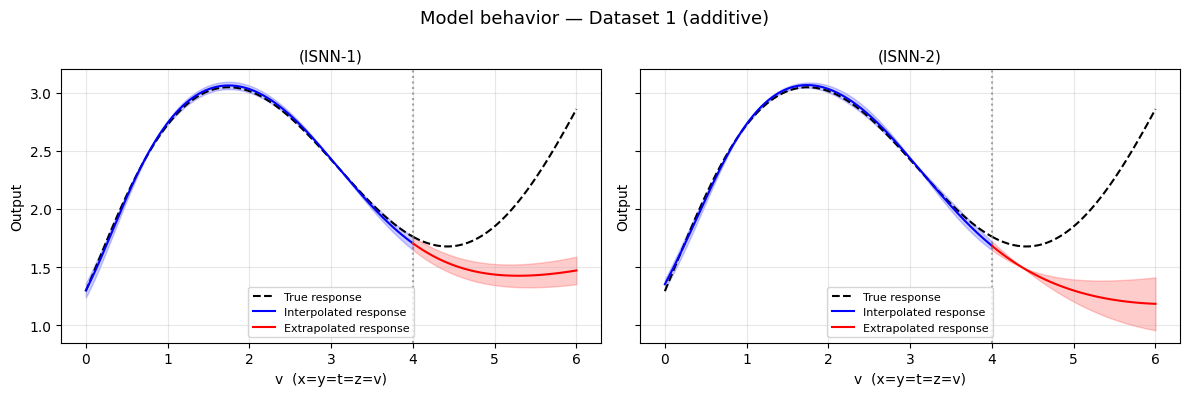

In [11]:
# We need to retrain a few models and keep the actual model objects this time
# (above we only saved losses). Let's train a small set for plotting.

def train_and_save_model(ModelClass, kwargs, X_train, y_train, X_test, y_test,
                          n_inits=3, n_epochs=8000, lr=1e-3):
    """Train multiple inits, return list of trained model objects."""
    saved = []
    for i in range(n_inits):
        torch.manual_seed(i)
        m = ModelClass(**kwargs)
        train_pytorch_model(m, X_train, y_train, X_test, y_test,
                            n_epochs=n_epochs, lr=lr, log_every=n_epochs)
        saved.append(m)
    return saved


# Dataset 1
print("Training models for Figure 4 plots...")
isnn1_d1_models = train_and_save_model(ISNN1, {"n_hidden": 10, "n_layers": 2},
                                        X1_train, y1_train, X1_test, y1_test)
isnn2_d1_models = train_and_save_model(ISNN2, {"n_hidden": 15, "n_layers": 2},
                                        X1_train, y1_train, X1_test, y1_test)

plot_behavior(
    [("ISNN-1", isnn1_d1_models), ("ISNN-2", isnn2_d1_models)],
    func1, [0, 4], [0, 6],
    "Dataset 1 (additive)"
)

Training models for Figure 6 plots...
  epoch  8000  |  train: 8.3470e-05  |  test: 9.3926e-03
  epoch  8000  |  train: 6.9289e-05  |  test: 6.5708e-03
  epoch  8000  |  train: 1.2490e-04  |  test: 1.4787e-02
  epoch  8000  |  train: 8.1566e-05  |  test: 1.0040e-02
  epoch  8000  |  train: 8.8644e-05  |  test: 1.1830e-02
  epoch  8000  |  train: 2.3596e-04  |  test: 3.1942e-02


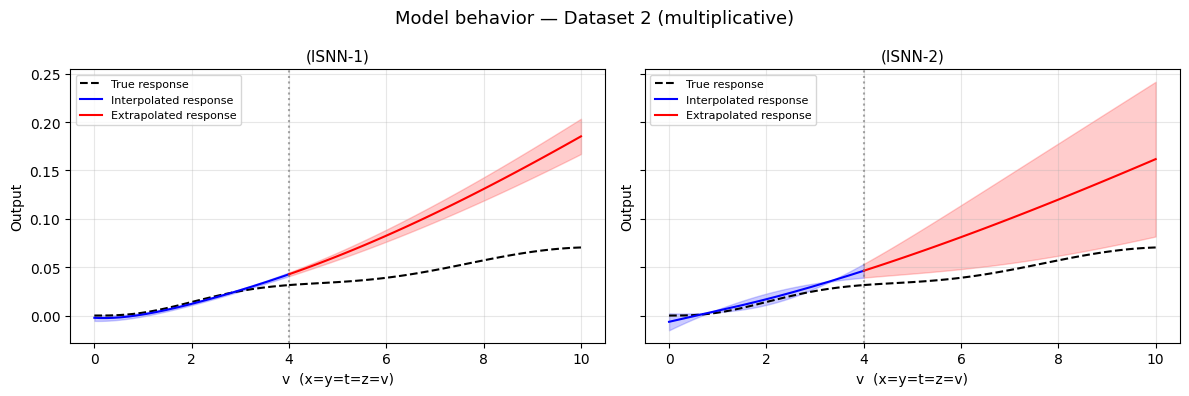

In [12]:
# Dataset 2
print("Training models for Figure 6 plots...")
isnn1_d2_models = train_and_save_model(ISNN1, {"n_hidden": 10, "n_layers": 2},
                                        X2_train, y2_train, X2_test, y2_test)
isnn2_d2_models = train_and_save_model(ISNN2, {"n_hidden": 15, "n_layers": 2},
                                        X2_train, y2_train, X2_test, y2_test)

plot_behavior(
    [("ISNN-1", isnn1_d2_models), ("ISNN-2", isnn2_d2_models)],
    func2, [0, 4], [0, 10],
    "Dataset 2 (multiplicative)"
)

---
## Section 3: Manual NumPy Implementation with Manual Backpropagation

We now implement ISNN-1 and ISNN-2 **from scratch** using only NumPy.
No automatic differentiation — all gradients are computed by hand.

The backpropagation derivations follow the chain rule applied to the
equations in the paper (Appendix A), adapted for mini-batch gradient descent.

### Activation functions and their derivatives

In [13]:
# ----------------------------------------------------------------
#  NumPy activation functions and their first derivatives
# ----------------------------------------------------------------

def np_softplus(x):
    """sigma_mc = log(1 + exp(x)) — convex and monotone."""
    return np.log1p(np.exp(np.clip(x, -500, 500)))

def np_softplus_prime(x):
    """Derivative of softplus = sigmoid(x)."""
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def np_sigmoid(x):
    """sigma_m = sigma_a = 1 / (1 + exp(-x))."""
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def np_sigmoid_prime(x):
    """Derivative of sigmoid = sig * (1 - sig)."""
    s = np_sigmoid(x)
    return s * (1.0 - s)

def relu_pos(w):
    """Soft way to enforce non-negative weights: we just take abs() like in PyTorch version."""
    return np.abs(w)


print("NumPy activations defined.")

NumPy activations defined.


### Manual ISNN-1 in NumPy

We maintain all parameters as dictionaries of numpy arrays.
The forward pass follows Eqs (1)-(5) exactly.
The backward pass follows the chain rule — we compute gradients
for each parameter layer by layer, starting from the output.

In [14]:
class ManualISNN1:
    """
    Hand-coded ISNN-1 in pure NumPy.
    Forward pass: Eqs (1)-(5) from the paper.
    Backward pass: manual chain rule (no autograd).

    Weight constraint (non-negativity) is enforced the same way as
    in the PyTorch version: we store raw weights and take abs() when using them.
    Gradients flow through abs() using the sign of the raw weight.
    """

    def __init__(self, n_hidden=10, n_layers=2, lr=1e-3, seed=0):
        rng = np.random.default_rng(seed)
        h   = n_hidden
        self.lr       = lr
        self.n_layers = n_layers
        self.h        = h

        def randn(r, c): return rng.standard_normal((r, c)) * 0.1
        def zeros(n):    return np.zeros(n)

        # ---- y-branch params (convex + monotone) ----
        self.Wyy = [randn(h, 1)]            # first layer: input dim=1
        self.by  = [zeros(h)]
        for _ in range(n_layers - 1):
            self.Wyy.append(randn(h, h))
            self.by.append(zeros(h))

        # ---- z-branch params (arbitrary) ----
        self.Wzz = [randn(h, 1)]
        self.bz  = [zeros(h)]
        for _ in range(n_layers - 1):
            self.Wzz.append(randn(h, h))
            self.bz.append(zeros(h))

        # ---- t-branch params (monotone) ----
        self.Wtt = [randn(h, 1)]
        self.bt  = [zeros(h)]
        for _ in range(n_layers - 1):
            self.Wtt.append(randn(h, h))
            self.bt.append(zeros(h))

        # ---- x-branch: layer 0 (merge layer) ----
        self.Wxx0 = randn(h, 1)     # x0 -> x1 (free)
        self.bx0  = zeros(h)
        self.Wxy  = randn(h, h)     # y_H -> x1 (must be >= 0)
        self.Wxz  = randn(h, h)     # z_H -> x1 (free)
        self.Wxt  = randn(h, h)     # t_H -> x1 (must be >= 0)

        # ---- x-branch: layers 1+ (W_xx must be >= 0) ----
        self.Wxx = [randn(h, h) for _ in range(n_layers - 1)]
        self.bx  = [zeros(h)    for _ in range(n_layers - 1)]

        # ---- output ----
        self.Wout = randn(1, h)
        self.bout = zeros(1)


    def forward(self, x, y, t, z):
        """Run forward pass, cache all intermediate values needed for backprop."""
        cache = {}

        # ---- y-branch ----
        hy = [y]     # hy[0] = input, hy[k] = activation after layer k
        gy = []      # pre-activation values
        for k in range(self.n_layers):
            W = relu_pos(self.Wyy[k])   # non-negative constraint
            g = hy[-1] @ W.T + self.by[k]
            gy.append(g)
            hy.append(np_softplus(g))

        # ---- z-branch ----
        hz = [z]
        gz = []
        for k in range(self.n_layers):
            g = hz[-1] @ self.Wzz[k].T + self.bz[k]
            gz.append(g)
            hz.append(np_sigmoid(g))

        # ---- t-branch ----
        ht = [t]
        gt = []
        for k in range(self.n_layers):
            W = relu_pos(self.Wtt[k])   # non-negative constraint
            g = ht[-1] @ W.T + self.bt[k]
            gt.append(g)
            ht.append(np_sigmoid(g))

        # ---- x-branch layer 0 (merge) ----
        Wxy_pos = relu_pos(self.Wxy)
        Wxt_pos = relu_pos(self.Wxt)
        gx0 = (x @ self.Wxx0.T + self.bx0
               + hy[-1] @ Wxy_pos.T
               + hz[-1] @ self.Wxz.T
               + ht[-1] @ Wxt_pos.T)
        hx = [np_softplus(gx0)]
        gx = [gx0]

        # ---- x-branch deeper layers ----
        for k in range(self.n_layers - 1):
            W_pos = relu_pos(self.Wxx[k])
            g = hx[-1] @ W_pos.T + self.bx[k]
            gx.append(g)
            hx.append(np_softplus(g))

        # ---- output ----
        out = hx[-1] @ self.Wout.T + self.bout

        cache = {"x": x, "y": y, "t": t, "z": z,
                 "hy": hy, "gy": gy,
                 "hz": hz, "gz": gz,
                 "ht": ht, "gt": gt,
                 "hx": hx, "gx": gx}
        return out, cache


    def backward(self, cache, y_pred, y_true):
        """
        Manual backpropagation through all layers.
        Returns a dict of gradients for every parameter.
        """
        N = y_true.shape[0]
        grads = {}

        # ---- Loss gradient: dL/d(y_pred) for MSE ----
        dout = 2 * (y_pred - y_true) / N    # shape: (N, 1)

        # ---- Output layer ----
        grads["Wout"] = dout.T @ cache["hx"][-1]   # (1, h)
        grads["bout"] = dout.sum(axis=0)             # (1,)
        d_hx_last = dout @ self.Wout                 # (N, h)

        # ---- x-branch backprop (deeper layers first) ----
        grads["Wxx"] = [None] * (self.n_layers - 1)
        grads["bx"]  = [None] * (self.n_layers - 1)

        d_hx = d_hx_last
        for k in range(self.n_layers - 2, -1, -1):
            # backprop through sigma_mc (softplus)
            d_gx = d_hx * np_softplus_prime(cache["gx"][k + 1])   # (N, h)

            W_pos = relu_pos(self.Wxx[k])   # we used abs(W)
            grads["Wxx"][k] = d_gx.T @ cache["hx"][k]   # (h, h)
            # chain rule through abs(): grad_raw = grad_pos * sign(raw_W)
            grads["Wxx"][k] = grads["Wxx"][k] * np.sign(self.Wxx[k])
            grads["bx"][k]  = d_gx.sum(axis=0)

            d_hx = d_gx @ W_pos   # pass gradient to previous x-layer

        # ---- x-branch layer 0 (merge layer) ----
        d_gx0 = d_hx * np_softplus_prime(cache["gx"][0])   # (N, h)

        # gradient for Wxx0 (free weights)
        grads["Wxx0"] = d_gx0.T @ cache["x"]       # (h, 1)
        grads["bx0"]  = d_gx0.sum(axis=0)           # (h,)

        # gradient for Wxy (non-negative)
        Wxy_pos = relu_pos(self.Wxy)
        dWxy_pos = d_gx0.T @ cache["hy"][-1]        # (h, h)
        grads["Wxy"] = dWxy_pos * np.sign(self.Wxy)
        d_hy_last = d_gx0 @ Wxy_pos                 # (N, h) — flow into y-branch

        # gradient for Wxz (free)
        grads["Wxz"] = d_gx0.T @ cache["hz"][-1]   # (h, h)
        d_hz_last = d_gx0 @ self.Wxz               # (N, h)

        # gradient for Wxt (non-negative)
        Wxt_pos = relu_pos(self.Wxt)
        dWxt_pos = d_gx0.T @ cache["ht"][-1]        # (h, h)
        grads["Wxt"] = dWxt_pos * np.sign(self.Wxt)
        d_ht_last = d_gx0 @ Wxt_pos                 # (N, h)

        # ---- y-branch backprop ----
        grads["Wyy"] = [None] * self.n_layers
        grads["by"]  = [None] * self.n_layers

        d_hy = d_hy_last
        for k in range(self.n_layers - 1, -1, -1):
            d_gy = d_hy * np_softplus_prime(cache["gy"][k])   # (N, h)
            W_pos = relu_pos(self.Wyy[k])
            grads["Wyy"][k] = (d_gy.T @ cache["hy"][k]) * np.sign(self.Wyy[k])
            grads["by"][k]  = d_gy.sum(axis=0)
            d_hy = d_gy @ W_pos

        # ---- z-branch backprop ----
        grads["Wzz"] = [None] * self.n_layers
        grads["bz"]  = [None] * self.n_layers

        d_hz = d_hz_last
        for k in range(self.n_layers - 1, -1, -1):
            d_gz = d_hz * np_sigmoid_prime(cache["gz"][k])
            grads["Wzz"][k] = d_gz.T @ cache["hz"][k]   # no positivity constraint
            grads["bz"][k]  = d_gz.sum(axis=0)
            d_hz = d_gz @ self.Wzz[k]

        # ---- t-branch backprop ----
        grads["Wtt"] = [None] * self.n_layers
        grads["bt"]  = [None] * self.n_layers

        d_ht = d_ht_last
        for k in range(self.n_layers - 1, -1, -1):
            d_gt = d_ht * np_sigmoid_prime(cache["gt"][k])
            W_pos = relu_pos(self.Wtt[k])
            grads["Wtt"][k] = (d_gt.T @ cache["ht"][k]) * np.sign(self.Wtt[k])
            grads["bt"][k]  = d_gt.sum(axis=0)
            d_ht = d_gt @ W_pos

        return grads


    def update(self, grads):
        """Simple SGD parameter update with learning rate."""
        lr = self.lr

        self.Wout -= lr * grads["Wout"]
        self.bout -= lr * grads["bout"]
        self.Wxx0 -= lr * grads["Wxx0"]
        self.bx0  -= lr * grads["bx0"]
        self.Wxy  -= lr * grads["Wxy"]
        self.Wxz  -= lr * grads["Wxz"]
        self.Wxt  -= lr * grads["Wxt"]

        for k in range(self.n_layers - 1):
            self.Wxx[k] -= lr * grads["Wxx"][k]
            self.bx[k]  -= lr * grads["bx"][k]

        for k in range(self.n_layers):
            self.Wyy[k] -= lr * grads["Wyy"][k]
            self.by[k]  -= lr * grads["by"][k]
            self.Wzz[k] -= lr * grads["Wzz"][k]
            self.bz[k]  -= lr * grads["bz"][k]
            self.Wtt[k] -= lr * grads["Wtt"][k]
            self.bt[k]  -= lr * grads["bt"][k]


    def predict(self, X):
        """Inference — split X into 4 input columns."""
        x, y, t, z = [X[:, i:i+1] for i in range(4)]
        out, _ = self.forward(x, y, t, z)
        return out


print("ManualISNN1 class defined.")

ManualISNN1 class defined.


In [15]:
class ManualISNN2:
    """
    Hand-coded ISNN-2 in pure NumPy.
    Key difference from ISNN-1: all branches share the same depth,
    and x0 is passed as a skip connection to every x-layer.
    """

    def __init__(self, n_hidden=15, n_layers=2, lr=1e-3, seed=0):
        rng = np.random.default_rng(seed)
        h   = n_hidden
        self.lr       = lr
        self.n_layers = n_layers
        self.h        = h

        def randn(r, c): return rng.standard_normal((r, c)) * 0.1
        def zeros(n):    return np.zeros(n)

        # ---- y-branch ----
        self.Wyy = [randn(h, 1)] + [randn(h, h) for _ in range(n_layers - 2)]
        self.by  = [zeros(h)]    + [zeros(h)    for _ in range(n_layers - 2)]

        # ---- z-branch ----
        self.Wzz = [randn(h, 1)] + [randn(h, h) for _ in range(n_layers - 2)]
        self.bz  = [zeros(h)]    + [zeros(h)    for _ in range(n_layers - 2)]

        # ---- t-branch ----
        self.Wtt = [randn(h, 1)] + [randn(h, h) for _ in range(n_layers - 2)]
        self.bt  = [zeros(h)]    + [zeros(h)    for _ in range(n_layers - 2)]

        # ---- x-branch layer 0 ----
        # combines x0, y0, z0, t0 directly (before branches are deep)
        self.Wxx0_init = randn(h, 1)    # x0 input (free)
        self.Wxy_init  = randn(h, h)    # y0 (must be >= 0)
        self.Wxz_init  = randn(h, h)    # z0 (free)
        self.Wxt_init  = randn(h, h)    # t0 (must be >= 0)
        self.bx_init   = zeros(h)

        # ---- x-branch layers h=1..H-1 ----
        n_deep = n_layers - 1
        self.Wxx  = [randn(h, h) for _ in range(n_deep)]   # >= 0
        self.Wxx0 = [randn(h, 1) for _ in range(n_deep)]   # skip from x0, free
        self.Wxy  = [randn(h, h) for _ in range(n_deep)]   # >= 0
        self.Wxz  = [randn(h, h) for _ in range(n_deep)]   # free
        self.Wxt  = [randn(h, h) for _ in range(n_deep)]   # >= 0
        self.bx   = [zeros(h)    for _ in range(n_deep)]

        # ---- output ----
        self.Wout = randn(1, h)
        self.bout = zeros(1)


    def forward(self, x0, y0, t0, z0):
        cache = {"x0": x0, "y0": y0, "t0": t0, "z0": z0}
        n_branch_layers = max(1, self.n_layers - 1)

        # ---- y-branch ----
        hy = [y0]; gy = []
        for k in range(n_branch_layers):
            W = relu_pos(self.Wyy[k])
            g = hy[-1] @ W.T + self.by[k]
            gy.append(g); hy.append(np_softplus(g))

        # ---- z-branch ----
        hz = [z0]; gz = []
        for k in range(n_branch_layers):
            g = hz[-1] @ self.Wzz[k].T + self.bz[k]
            gz.append(g); hz.append(np_sigmoid(g))

        # ---- t-branch ----
        ht = [t0]; gt = []
        for k in range(n_branch_layers):
            W = relu_pos(self.Wtt[k])
            g = ht[-1] @ W.T + self.bt[k]
            gt.append(g); ht.append(np_sigmoid(g))

        # ---- x-branch layer 0 ----
        Wxy0_pos = relu_pos(self.Wxy_init)
        Wxt0_pos = relu_pos(self.Wxt_init)
        gx0 = (x0 @ self.Wxx0_init.T
               + hy[-1] @ Wxy0_pos.T
               + hz[-1] @ self.Wxz_init.T
               + ht[-1] @ Wxt0_pos.T
               + self.bx_init)
        hx = [np_softplus(gx0)]; gx = [gx0]

        # ---- x-branch deeper layers (with skip from x0) ----
        n_deep = self.n_layers - 1
        for k in range(n_deep):
            Wxx_pos = relu_pos(self.Wxx[k])
            Wxy_pos = relu_pos(self.Wxy[k])
            Wxt_pos = relu_pos(self.Wxt[k])
            g = (hx[-1] @ Wxx_pos.T
                 + x0    @ self.Wxx0[k].T
                 + hy[-1] @ Wxy_pos.T
                 + hz[-1] @ self.Wxz[k].T
                 + ht[-1] @ Wxt_pos.T
                 + self.bx[k])
            gx.append(g); hx.append(np_softplus(g))

        out = hx[-1] @ self.Wout.T + self.bout

        cache.update({"hy": hy, "gy": gy, "hz": hz, "gz": gz,
                      "ht": ht, "gt": gt, "hx": hx, "gx": gx})
        return out, cache


    def backward(self, cache, y_pred, y_true):
        N = y_true.shape[0]
        grads = {}

        dout = 2 * (y_pred - y_true) / N

        # output layer
        grads["Wout"] = dout.T @ cache["hx"][-1]
        grads["bout"] = dout.sum(axis=0)
        d_hx = dout @ self.Wout   # (N, h)

        # accumulators for branch gradients (since branches feed into each x-layer)
        d_hy_acc = np.zeros_like(cache["hy"][-1])
        d_hz_acc = np.zeros_like(cache["hz"][-1])
        d_ht_acc = np.zeros_like(cache["ht"][-1])
        d_x0_acc = np.zeros_like(cache["x0"])

        n_deep = self.n_layers - 1
        grads["Wxx"]  = [None] * n_deep
        grads["Wxx0"] = [None] * n_deep
        grads["Wxy"]  = [None] * n_deep
        grads["Wxz"]  = [None] * n_deep
        grads["Wxt"]  = [None] * n_deep
        grads["bx"]   = [None] * n_deep

        # backprop through deeper x-layers
        for k in range(n_deep - 1, -1, -1):
            d_gx = d_hx * np_softplus_prime(cache["gx"][k + 1])

            Wxx_pos = relu_pos(self.Wxx[k])
            Wxy_pos = relu_pos(self.Wxy[k])
            Wxt_pos = relu_pos(self.Wxt[k])

            grads["Wxx"][k]  = (d_gx.T @ cache["hx"][k + 1]) * np.sign(self.Wxx[k])
            grads["Wxx0"][k] = d_gx.T @ cache["x0"]
            grads["Wxy"][k]  = (d_gx.T @ cache["hy"][-1]) * np.sign(self.Wxy[k])
            grads["Wxz"][k]  = d_gx.T @ cache["hz"][-1]
            grads["Wxt"][k]  = (d_gx.T @ cache["ht"][-1]) * np.sign(self.Wxt[k])
            grads["bx"][k]   = d_gx.sum(axis=0)

            # accumulate gradients into branches and skip connection
            d_hy_acc += d_gx @ Wxy_pos
            d_hz_acc += d_gx @ self.Wxz[k]
            d_ht_acc += d_gx @ Wxt_pos
            d_x0_acc += d_gx @ self.Wxx0[k]

            d_hx = d_gx @ Wxx_pos

        # backprop through x-branch layer 0
        d_gx0 = d_hx * np_softplus_prime(cache["gx"][0])

        Wxy0_pos = relu_pos(self.Wxy_init)
        Wxt0_pos = relu_pos(self.Wxt_init)

        grads["Wxx0_init"] = d_gx0.T @ cache["x0"]
        grads["Wxy_init"]  = (d_gx0.T @ cache["hy"][-1]) * np.sign(self.Wxy_init)
        grads["Wxz_init"]  = d_gx0.T @ cache["hz"][-1]
        grads["Wxt_init"]  = (d_gx0.T @ cache["ht"][-1]) * np.sign(self.Wxt_init)
        grads["bx_init"]   = d_gx0.sum(axis=0)

        d_hy_acc += d_gx0 @ Wxy0_pos
        d_hz_acc += d_gx0 @ self.Wxz_init
        d_ht_acc += d_gx0 @ Wxt0_pos
        d_x0_acc += d_gx0 @ self.Wxx0_init

        n_branch_layers = max(1, self.n_layers - 1)

        # ---- y-branch backprop ----
        grads["Wyy"] = [None] * n_branch_layers
        grads["by"]  = [None] * n_branch_layers
        d_hy = d_hy_acc
        for k in range(n_branch_layers - 1, -1, -1):
            d_gy = d_hy * np_softplus_prime(cache["gy"][k])
            W_pos = relu_pos(self.Wyy[k])
            grads["Wyy"][k] = (d_gy.T @ cache["hy"][k]) * np.sign(self.Wyy[k])
            grads["by"][k]  = d_gy.sum(axis=0)
            d_hy = d_gy @ W_pos

        # ---- z-branch backprop ----
        grads["Wzz"] = [None] * n_branch_layers
        grads["bz"]  = [None] * n_branch_layers
        d_hz = d_hz_acc
        for k in range(n_branch_layers - 1, -1, -1):
            d_gz = d_hz * np_sigmoid_prime(cache["gz"][k])
            grads["Wzz"][k] = d_gz.T @ cache["hz"][k]
            grads["bz"][k]  = d_gz.sum(axis=0)
            d_hz = d_gz @ self.Wzz[k]

        # ---- t-branch backprop ----
        grads["Wtt"] = [None] * n_branch_layers
        grads["bt"]  = [None] * n_branch_layers
        d_ht = d_ht_acc
        for k in range(n_branch_layers - 1, -1, -1):
            d_gt = d_ht * np_sigmoid_prime(cache["gt"][k])
            W_pos = relu_pos(self.Wtt[k])
            grads["Wtt"][k] = (d_gt.T @ cache["ht"][k]) * np.sign(self.Wtt[k])
            grads["bt"][k]  = d_gt.sum(axis=0)
            d_ht = d_gt @ W_pos

        return grads


    def update(self, grads):
        lr = self.lr
        self.Wout        -= lr * grads["Wout"]
        self.bout        -= lr * grads["bout"]
        self.Wxx0_init   -= lr * grads["Wxx0_init"]
        self.Wxy_init    -= lr * grads["Wxy_init"]
        self.Wxz_init    -= lr * grads["Wxz_init"]
        self.Wxt_init    -= lr * grads["Wxt_init"]
        self.bx_init     -= lr * grads["bx_init"]

        n_deep = self.n_layers - 1
        for k in range(n_deep):
            self.Wxx[k]  -= lr * grads["Wxx"][k]
            self.Wxx0[k] -= lr * grads["Wxx0"][k]
            self.Wxy[k]  -= lr * grads["Wxy"][k]
            self.Wxz[k]  -= lr * grads["Wxz"][k]
            self.Wxt[k]  -= lr * grads["Wxt"][k]
            self.bx[k]   -= lr * grads["bx"][k]

        n_branch_layers = max(1, self.n_layers - 1)
        for k in range(n_branch_layers):
            self.Wyy[k] -= lr * grads["Wyy"][k]
            self.by[k]  -= lr * grads["by"][k]
            self.Wzz[k] -= lr * grads["Wzz"][k]
            self.bz[k]  -= lr * grads["bz"][k]
            self.Wtt[k] -= lr * grads["Wtt"][k]
            self.bt[k]  -= lr * grads["bt"][k]


    def predict(self, X):
        x, y, t, z = [X[:, i:i+1] for i in range(4)]
        out, _ = self.forward(x, y, t, z)
        return out


print("ManualISNN2 class defined.")

ManualISNN2 class defined.


### Manual Training Loop

In [16]:
def train_manual_model(model, X_train, y_train, X_test, y_test,
                        n_epochs=5000, log_every=500):
    """
    Full batch gradient descent with manual backprop.
    Returns training and test loss arrays.
    """
    x_tr, y_tr_in, t_tr, z_tr = [X_train[:, i:i+1] for i in range(4)]
    x_te, y_te_in, t_te, z_te = [X_test[:, i:i+1]  for i in range(4)]

    train_losses, test_losses = [], []

    for epoch in range(n_epochs):
        # forward pass
        pred, cache = model.forward(x_tr, y_tr_in, t_tr, z_tr)

        # compute MSE loss
        loss = np.mean((pred - y_train) ** 2)
        train_losses.append(loss)

        # backward pass
        grads = model.backward(cache, pred, y_train)

        # parameter update
        model.update(grads)

        # test loss (no grad needed)
        pred_te = model.predict(X_test)
        te_loss = np.mean((pred_te - y_test) ** 2)
        test_losses.append(te_loss)

        if (epoch + 1) % log_every == 0:
            print(f"  epoch {epoch+1:5d}  |  train: {loss:.4e}  |  test: {te_loss:.4e}")

    return np.array(train_losses), np.array(test_losses)


print("Manual training loop defined.")

Manual training loop defined.


In [17]:
# Manual models — using fewer epochs since full-batch SGD is slower to converge
# but is pedagogically accurate for demonstrating manual backprop

N_MANUAL_EPOCHS = 3000
N_MANUAL_INITS  = 3
MANUAL_LR       = 5e-3

manual_results_d1 = {"ISNN1_train": [], "ISNN1_test": [],
                      "ISNN2_train": [], "ISNN2_test": []}

print("=== Manual ISNN-1 — Dataset 1 ===")
for i in range(N_MANUAL_INITS):
    np.random.seed(i)
    m = ManualISNN1(n_hidden=10, n_layers=2, lr=MANUAL_LR, seed=i)
    tr, te = train_manual_model(m, X1_train, y1_train, X1_test, y1_test,
                                 n_epochs=N_MANUAL_EPOCHS, log_every=N_MANUAL_EPOCHS)
    manual_results_d1["ISNN1_train"].append(tr)
    manual_results_d1["ISNN1_test"].append(te)
    print(f"  init {i+1}/{N_MANUAL_INITS} done")

print("\n=== Manual ISNN-2 — Dataset 1 ===")
for i in range(N_MANUAL_INITS):
    np.random.seed(i)
    m = ManualISNN2(n_hidden=15, n_layers=2, lr=MANUAL_LR, seed=i)
    tr, te = train_manual_model(m, X1_train, y1_train, X1_test, y1_test,
                                 n_epochs=N_MANUAL_EPOCHS, log_every=N_MANUAL_EPOCHS)
    manual_results_d1["ISNN2_train"].append(tr)
    manual_results_d1["ISNN2_test"].append(te)
    print(f"  init {i+1}/{N_MANUAL_INITS} done")

for k in manual_results_d1:
    manual_results_d1[k] = np.array(manual_results_d1[k])

=== Manual ISNN-1 — Dataset 1 ===
  epoch  3000  |  train: 3.4329e-01  |  test: 6.8699e-01
  init 1/3 done
  epoch  3000  |  train: 3.4370e-01  |  test: 6.8020e-01
  init 2/3 done
  epoch  3000  |  train: 3.4175e-01  |  test: 6.8604e-01
  init 3/3 done

=== Manual ISNN-2 — Dataset 1 ===
  epoch  3000  |  train: 2.1360e-01  |  test: 3.2872e-01
  init 1/3 done
  epoch  3000  |  train: 2.2424e-01  |  test: 3.9616e-01
  init 2/3 done
  epoch  3000  |  train: 2.2054e-01  |  test: 3.5645e-01
  init 3/3 done


In [18]:
manual_results_d2 = {"ISNN1_train": [], "ISNN1_test": [],
                      "ISNN2_train": [], "ISNN2_test": []}

print("=== Manual ISNN-1 — Dataset 2 ===")
for i in range(N_MANUAL_INITS):
    m = ManualISNN1(n_hidden=10, n_layers=2, lr=MANUAL_LR, seed=i)
    tr, te = train_manual_model(m, X2_train, y2_train, X2_test, y2_test,
                                 n_epochs=N_MANUAL_EPOCHS, log_every=N_MANUAL_EPOCHS)
    manual_results_d2["ISNN1_train"].append(tr)
    manual_results_d2["ISNN1_test"].append(te)
    print(f"  init {i+1}/{N_MANUAL_INITS} done")

print("\n=== Manual ISNN-2 — Dataset 2 ===")
for i in range(N_MANUAL_INITS):
    m = ManualISNN2(n_hidden=15, n_layers=2, lr=MANUAL_LR, seed=i)
    tr, te = train_manual_model(m, X2_train, y2_train, X2_test, y2_test,
                                 n_epochs=N_MANUAL_EPOCHS, log_every=N_MANUAL_EPOCHS)
    manual_results_d2["ISNN2_train"].append(tr)
    manual_results_d2["ISNN2_test"].append(te)
    print(f"  init {i+1}/{N_MANUAL_INITS} done")

for k in manual_results_d2:
    manual_results_d2[k] = np.array(manual_results_d2[k])

=== Manual ISNN-1 — Dataset 2 ===
  epoch  3000  |  train: 6.0343e-04  |  test: 2.1032e-02
  init 1/3 done
  epoch  3000  |  train: 5.0207e-04  |  test: 2.1440e-02
  init 2/3 done
  epoch  3000  |  train: 4.7038e-04  |  test: 2.0924e-02
  init 3/3 done

=== Manual ISNN-2 — Dataset 2 ===
  epoch  3000  |  train: 3.7369e-04  |  test: 1.8709e-02
  init 1/3 done
  epoch  3000  |  train: 4.4244e-04  |  test: 2.2262e-02
  init 2/3 done
  epoch  3000  |  train: 3.7423e-04  |  test: 1.7978e-02
  init 3/3 done


### Loss Curves for Manual Models

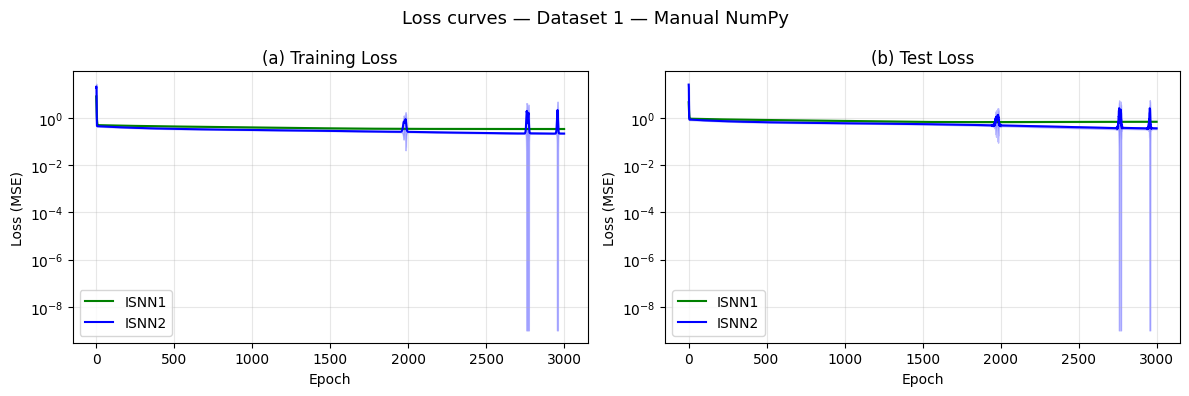

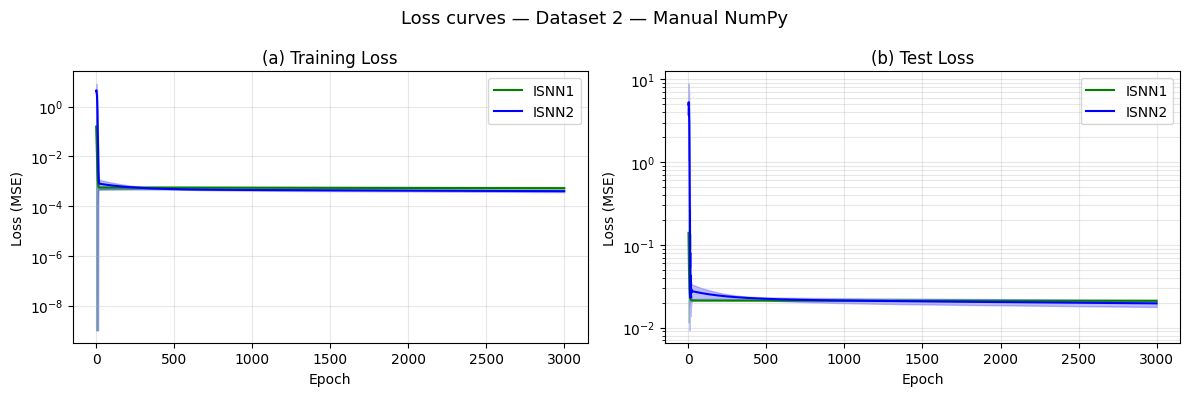

In [19]:
plot_loss_curves(manual_results_d1, "Dataset 1 — Manual NumPy", N_MANUAL_EPOCHS)
plot_loss_curves(manual_results_d2, "Dataset 2 — Manual NumPy", N_MANUAL_EPOCHS)

### Behavior Plots for Manual Models

Training manual models for behavior plots...
  epoch  3000  |  train: 3.4329e-01  |  test: 6.8699e-01
  epoch  3000  |  train: 3.4370e-01  |  test: 6.8020e-01
  epoch  3000  |  train: 3.4175e-01  |  test: 6.8604e-01
  epoch  3000  |  train: 2.1360e-01  |  test: 3.2872e-01
  epoch  3000  |  train: 2.2424e-01  |  test: 3.9616e-01
  epoch  3000  |  train: 2.2054e-01  |  test: 3.5645e-01


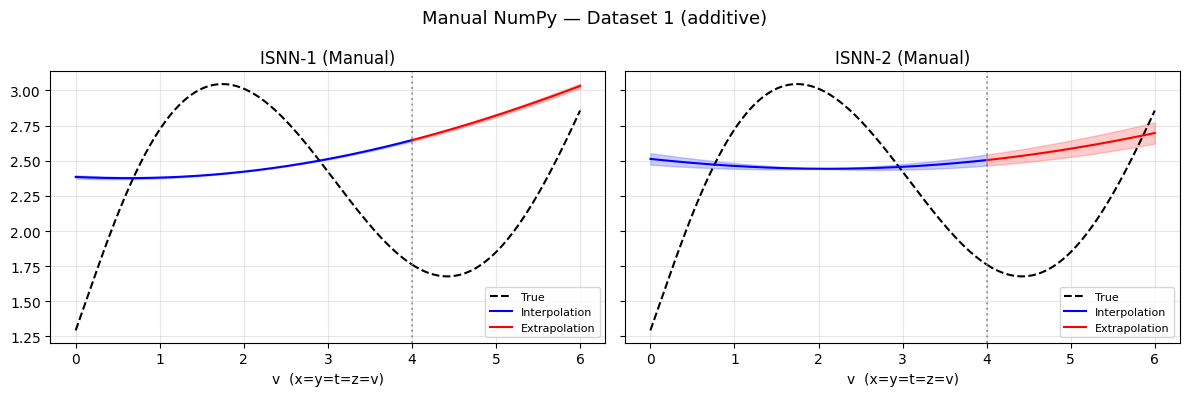

In [20]:
def plot_manual_behavior(manual_model_list, fn, train_range, test_range, title_suffix):
    """
    Same idea as plot_behavior but for numpy manual models.
    Evaluate along the diagonal v where x=y=t=z=v.
    """
    v_interp = np.linspace(train_range[0], train_range[1], 200)
    v_extrap = np.linspace(train_range[1], test_range[1], 100)
    v_all    = np.concatenate([v_interp, v_extrap])
    true_all = fn(v_all, v_all, v_all, v_all)

    # stack into input matrix [v, v, v, v]
    V = np.stack([v_all, v_all, v_all, v_all], axis=1)

    fig, axes = plt.subplots(1, len(manual_model_list), figsize=(6 * len(manual_model_list), 4), sharey=True)
    if len(manual_model_list) == 1:
        axes = [axes]

    for ax, (label, model_list) in zip(axes, manual_model_list):
        preds = []
        for m in model_list:
            p = m.predict(V).squeeze()
            preds.append(p)

        preds = np.array(preds)
        mean_p = preds.mean(0)
        std_p  = preds.std(0)

        n_i = len(v_interp)
        ax.plot(v_all[:n_i], true_all[:n_i], 'k--', label='True')
        ax.plot(v_all[n_i:], true_all[n_i:], 'k--')

        ax.plot(v_all[:n_i], mean_p[:n_i], 'b-', label='Interpolation')
        ax.fill_between(v_all[:n_i], mean_p[:n_i]-std_p[:n_i], mean_p[:n_i]+std_p[:n_i],
                        alpha=0.2, color='blue')

        ax.plot(v_all[n_i:], mean_p[n_i:], 'r-', label='Extrapolation')
        ax.fill_between(v_all[n_i:], mean_p[n_i:]-std_p[n_i:], mean_p[n_i:]+std_p[n_i:],
                        alpha=0.2, color='red')

        ax.axvline(train_range[1], linestyle=':', color='gray', alpha=0.7)
        ax.set_title(label)
        ax.set_xlabel("v  (x=y=t=z=v)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f"Manual NumPy — {title_suffix}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"behavior_manual_{title_suffix.replace(' ','_')}.png", dpi=120, bbox_inches='tight')
    plt.show()


# train manual models and keep them for plotting
def train_manual_and_save(ModelClass, kwargs, X_train, y_train, X_test, y_test,
                            n_inits=3, n_epochs=3000, lr=5e-3):
    saved = []
    for i in range(n_inits):
        m = ModelClass(**kwargs, lr=lr, seed=i)
        train_manual_model(m, X_train, y_train, X_test, y_test,
                           n_epochs=n_epochs, log_every=n_epochs)
        saved.append(m)
    return saved


print("Training manual models for behavior plots...")
m_isnn1_d1 = train_manual_and_save(ManualISNN1, {"n_hidden": 10, "n_layers": 2},
                                    X1_train, y1_train, X1_test, y1_test)
m_isnn2_d1 = train_manual_and_save(ManualISNN2, {"n_hidden": 15, "n_layers": 2},
                                    X1_train, y1_train, X1_test, y1_test)

plot_manual_behavior(
    [("ISNN-1 (Manual)", m_isnn1_d1), ("ISNN-2 (Manual)", m_isnn2_d1)],
    func1, [0, 4], [0, 6], "Dataset 1 (additive)"
)

  epoch  3000  |  train: 6.0343e-04  |  test: 2.1032e-02
  epoch  3000  |  train: 5.0207e-04  |  test: 2.1440e-02
  epoch  3000  |  train: 4.7038e-04  |  test: 2.0924e-02
  epoch  3000  |  train: 3.7369e-04  |  test: 1.8709e-02
  epoch  3000  |  train: 4.4244e-04  |  test: 2.2262e-02
  epoch  3000  |  train: 3.7423e-04  |  test: 1.7978e-02


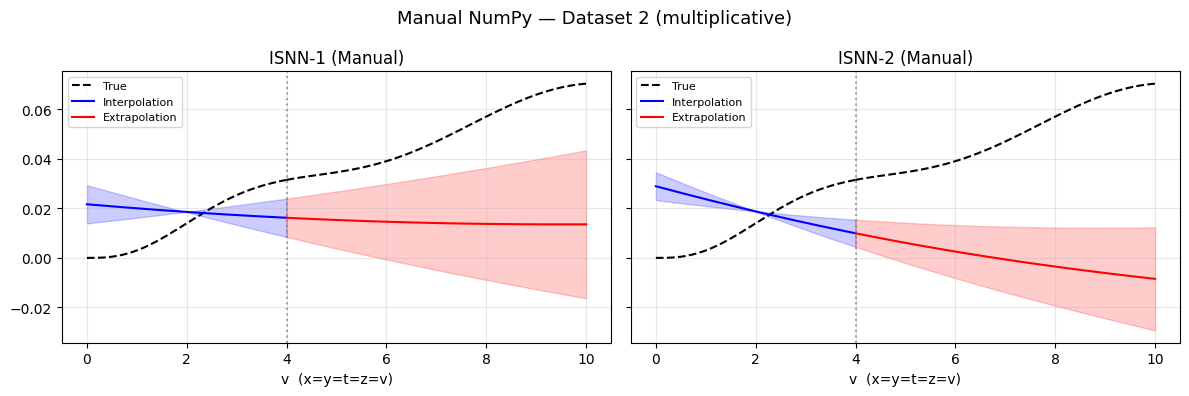

In [21]:
m_isnn1_d2 = train_manual_and_save(ManualISNN1, {"n_hidden": 10, "n_layers": 2},
                                    X2_train, y2_train, X2_test, y2_test)
m_isnn2_d2 = train_manual_and_save(ManualISNN2, {"n_hidden": 15, "n_layers": 2},
                                    X2_train, y2_train, X2_test, y2_test)

plot_manual_behavior(
    [("ISNN-1 (Manual)", m_isnn1_d2), ("ISNN-2 (Manual)", m_isnn2_d2)],
    func2, [0, 4], [0, 10], "Dataset 2 (multiplicative)"
)

---
## Section 4: Summary and Comparison

A final side-by-side comparison of final test losses across all implementations.

In [22]:
def final_loss_summary(pt_results, manual_results, dataset_name):
    """Print a clean table of final test losses."""
    print(f"\n{'='*55}")
    print(f"  Final test losses — {dataset_name}")
    print(f"{'='*55}")
    print(f"  {'Model':<30} {'Mean':>10} {'Std':>10}")
    print(f"  {'-'*50}")

    for label, arr in [("PyTorch ISNN-1", pt_results["ISNN1_test"]),
                        ("PyTorch ISNN-2", pt_results["ISNN2_test"]),
                        ("NumPy ISNN-1 (manual backprop)", manual_results["ISNN1_test"]),
                        ("NumPy ISNN-2 (manual backprop)", manual_results["ISNN2_test"])]:
        final = arr[:, -1]   # last epoch values
        print(f"  {label:<30} {final.mean():>10.4e} {final.std():>10.4e}")


final_loss_summary(results_d1, manual_results_d1, "Dataset 1 (additive)")
final_loss_summary(results_d2, manual_results_d2, "Dataset 2 (multiplicative)")


  Final test losses — Dataset 1 (additive)
  Model                                Mean        Std
  --------------------------------------------------
  PyTorch ISNN-1                 9.0041e-02 1.6364e-02
  PyTorch ISNN-2                 1.9735e-01 7.5841e-02
  NumPy ISNN-1 (manual backprop) 6.8441e-01 3.0047e-03
  NumPy ISNN-2 (manual backprop) 3.6044e-01 2.7677e-02

  Final test losses — Dataset 2 (multiplicative)
  Model                                Mean        Std
  --------------------------------------------------
  PyTorch ISNN-1                 8.8323e-03 2.6052e-03
  PyTorch ISNN-2                 1.2946e-02 3.1129e-03
  NumPy ISNN-1 (manual backprop) 2.1132e-02 2.2254e-04
  NumPy ISNN-2 (manual backprop) 1.9650e-02 1.8712e-03


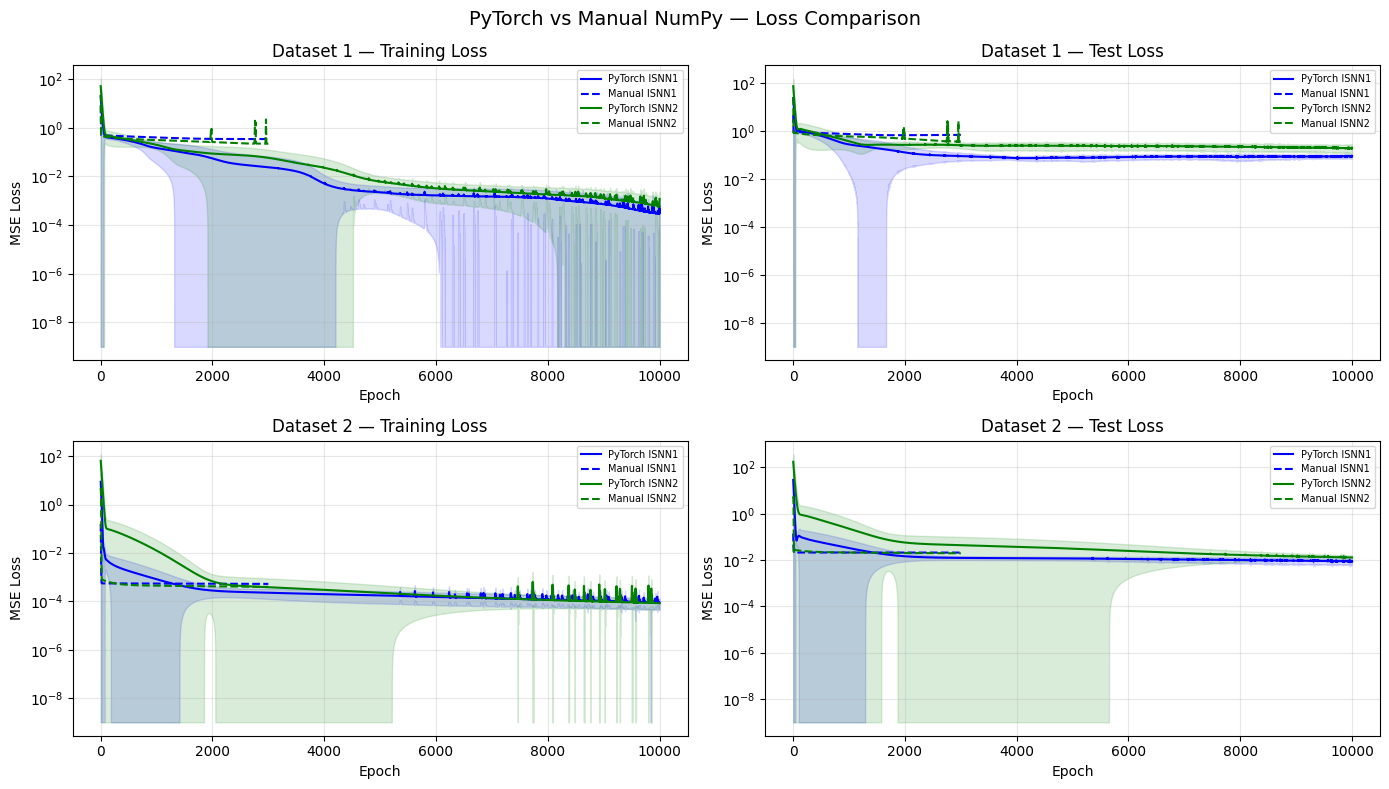

All plots saved. Assignment complete.


In [23]:
# final combined plot — PyTorch vs Manual, both datasets
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
titles = ["Dataset 1 — Training Loss", "Dataset 1 — Test Loss",
           "Dataset 2 — Training Loss", "Dataset 2 — Test Loss"]

pt_keys   = [("results_d1", "_train"), ("results_d1", "_test"),
              ("results_d2", "_train"), ("results_d2", "_test")]
man_keys  = [("manual_results_d1", "_train"), ("manual_results_d1", "_test"),
              ("manual_results_d2", "_train"), ("manual_results_d2", "_test")]

all_pt     = [results_d1, results_d1, results_d2, results_d2]
all_man    = [manual_results_d1, manual_results_d1, manual_results_d2, manual_results_d2]
which_loss = ["_train", "_test", "_train", "_test"]

for idx, ax in enumerate(axes.flatten()):
    pt_r  = all_pt[idx]
    man_r = all_man[idx]
    key   = which_loss[idx]

    for arch, color in [("ISNN1", "blue"), ("ISNN2", "green")]:
        pt_arr = pt_r[arch + key]
        ep_pt  = np.arange(1, pt_arr.shape[1] + 1)
        ax.semilogy(ep_pt, pt_arr.mean(0), color=color,
                    linestyle='-', label=f"PyTorch {arch}")
        ax.fill_between(ep_pt,
                         np.clip(pt_arr.mean(0) - pt_arr.std(0), 1e-9, None),
                         pt_arr.mean(0) + pt_arr.std(0),
                         alpha=0.15, color=color)

        man_arr = man_r[arch + key]
        ep_man  = np.arange(1, man_arr.shape[1] + 1)
        ax.semilogy(ep_man, man_arr.mean(0), color=color,
                    linestyle='--', label=f"Manual {arch}")

    ax.set_title(titles[idx])
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend(fontsize=7)
    ax.grid(True, which='both', alpha=0.3)

fig.suptitle("PyTorch vs Manual NumPy — Loss Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("combined_comparison.png", dpi=120, bbox_inches='tight')
plt.show()

print("All plots saved. Assignment complete.")